<a href="https://colab.research.google.com/github/bihjane/Data-science-and-AI-K-12-teaching-tools/blob/main/LR_SquareFeet_Only_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Predicting Home Price from Square Footage
### Loudoun County, VA Housing Data — pandas, matplotlib, scikit-learn

**Purpose of this notebook:** This is a teaching notebook built for CS/data-science
teacher professional development. It walks through a complete, minimal linear
regression workflow using **one predictor variable** (square footage) to estimate
home price. A companion notebook (`LR_Multiple_Features.ipynb`) extends this same
dataset to multiple numeric predictors plus a categorical variable.

**What you will practice here:**
1. Loading and cleaning real (messy) data with `pandas`
2. Exploring a relationship visually with `matplotlib`
3. Splitting data into training and test sets
4. Scaling a feature with `StandardScaler`
5. Fitting a `LinearRegression` model with `scikit-learn`
6. Reading and interpreting the model's weight (coefficient) and intercept
7. Evaluating the model with standard regression metrics
8. Producing several diagnostic visualizations

**A note on the data, up front:** this dataset has only **47 rows**. That is fine
for demonstrating *how the tools work*, but it is far too small to draw real
conclusions about the Loudoun County housing market. Treat every metric below as
an illustration of technique, not as a validated model. This is worth saying
explicitly to students — a common misconception is that a high R² on a tiny
sample means the model is "good."


## 1. About the dataset

The source file (`loudoun_housing.csv`, pulled from Google Drive) is a small,
manually-assembled sample of home listings from Loudoun County, VA (and a few
neighboring towns), with these raw columns:

| Column | Description | Type as stored in the CSV |
|---|---|---|
| `Price in 1,000's` | Listing price, already expressed in units of \$1,000 (e.g. `$337.50` means \$337,500) | text, formatted like currency (`$337.50`) |
| `Bedrooms` | Number of bedrooms | integer |
| `Bathrooms` | Number of bathrooms (half-baths count as `.5`) | float |
| `Square Feet` | Finished square footage | integer |
| `House type` | `Condo`, `Townhome`, or `Detached` | text |
| `Address`, `City` | Location fields — not used as model features here | text |

One important, honest observation about this file: the price column's header
(`Price in 1,000's`) already tells us the units — the numeric part of
`$337.50` **is** 337.50 thousand dollars. We do **not** divide it by 1,000
again — that would incorrectly turn a \$337,500 home into a "\$0.34" home.
What we *do* need to do is strip the `$` formatting so pandas treats it as a
number instead of text. Worth calling out explicitly: always read what a
column actually contains, not just what you assume from its name.


## 2. Import libraries

- **pandas** — loading, cleaning, and manipulating tabular data
- **numpy** — numeric operations (arrays, sorting for plotting a smooth line)
- **matplotlib.pyplot** — all of our charts
- **scikit-learn** — `train_test_split` for evaluation methodology,
  `StandardScaler` for feature scaling, `LinearRegression` for the model itself,
  and metric functions to judge how well it fits


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots a comfortable size and slightly higher resolution by default
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100


## 3. Load the data

The dataset lives in Google Drive, so we download it directly with
[`gdown`](https://github.com/wkentaro/gdown) rather than requiring a manual
file upload each time the notebook runs. `gdown` needs the file's Google
Drive **file ID**, which is the long string of characters in the share link
between `/d/` and `/view`:

`https://drive.google.com/file/d/`**`1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2`**`/view?usp=sharing`

The file must be shared as "Anyone with the link can view" for this to work
without authentication — if you get a permissions error instead of a CSV,
that's the first thing to check.


In [ ]:
# gdown ships preinstalled in Colab; the -q install here is just a safety net
# for local Jupyter environments where it might be missing.
!pip install -q gdown

import gdown

FILE_ID = "1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2"
FILENAME = "loudoun_housing.csv"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", FILENAME, quiet=False)

raw_df = pd.read_csv(FILENAME)
raw_df.head()


Downloading...
From: https://drive.google.com/uc?id=1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2
To: /content/loudoun_housing.csv
100%|██████████| 2.40k/2.40k [00:00<00:00, 2.65MB/s]


,Price_thousands,Bedrooms,Bathrooms,Square Feet,House type,Address,City
0,338,3,2,1534,Condo,19375 cypress ridge Terr,Leesburg
1,740,4,5,4472,Detached,24970 greengage PL,aldi
2,817,4,5,6824,Detached,22770 brookshade dr,ashburn
3,353,3,3,2060,Townhome,6 Paxton Ct,sterling
4,358,3,3,1720,Townhome,21807 learleaf cir,sterling


## 4. Look before you touch anything

Always inspect a new dataset before cleaning it: check its shape, its column
types, and whether anything looks obviously wrong (extra columns, mismatched
types, stray whitespace). Notice that `Price in 1,000's` is loaded as text
(`object`/string), not a number — that's our first clean-up task.


In [ ]:
print("Shape (rows, columns):", raw_df.shape)
print()
print("Column data types:")
print(raw_df.dtypes)
print()
print("Missing values per column:")
print(raw_df.isna().sum())


Shape (rows, columns): (47, 7)

Column data types:
Price_thousands     int64
Bedrooms            int64
Bathrooms           int64
Square Feet         int64
House type         object
Address            object
City               object
dtype: object

Missing values per column:
Price_thousands    0
Bedrooms           0
Bathrooms          0
Square Feet        0
House type         0
Address            0
City               0
dtype: int64


The raw file also carries two unlabeled columns (`Unnamed: 7`, `Unnamed: 8`)
left over from scratch calculations in the original spreadsheet. We'll drop
those — they're not part of the dataset we actually want to model.


## 5. Clean the data

Two cleaning steps:

1. **Price** — strip the `$` (and any stray commas) from `Price in 1,000's` and
   convert to a float. As discussed above, we do *not* divide by 1,000 again;
   the column is already in those units. We rename it to `Price_thousands` so
   the units are unambiguous in code.
2. **Keep only the columns this notebook needs.** This version of the file
   has `House type` capitalization already consistent, so no text
   normalization is needed there — but it's still worth printing the value
   counts below as a quick sanity check rather than assuming that's true.


In [ ]:
df = raw_df.copy()

df = df[["Square Feet", "Price_thousands", "House type", "Bedrooms", "Bathrooms"]]

print(df["House type"].value_counts())
print()
df.describe()


House type
Detached    28
Townhome    15
Condo        4
Name: count, dtype: int64



,Square Feet,Price_thousands,Bedrooms,Bathrooms
count,47.000000,47.000000,47.000000,47.000000
mean,3327.468085,574.638298,3.723404,3.893617
std,1545.467297,181.883076,0.877301,1.026477
min,853.000000,278.000000,2.000000,2.000000
25%,2231.000000,424.500000,3.000000,3.000000
50%,3268.000000,604.000000,4.000000,4.000000
75%,4484.500000,699.500000,4.000000,5.000000
max,6824.000000,1000.000000,6.000000,6.000000


## 6. Visualize the relationship first

Before fitting any model, plot the two variables you're about to relate. This
is good practice generally: a model should never be your *first* look at the
data. A scatter plot lets you sanity-check that (a) a roughly linear
relationship is plausible, and (b) there are no obvious outliers or data-entry
errors.


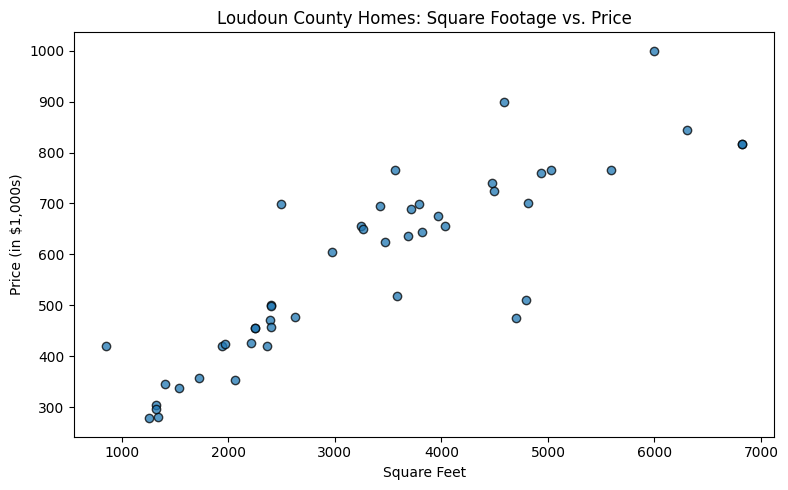

In [ ]:
plt.scatter(df["Square Feet"], df["Price_thousands"], alpha=0.75, edgecolor="k")
plt.xlabel("Square Feet")
plt.ylabel("Price (in $1,000s)")
plt.title("Loudoun County Homes: Square Footage vs. Price")
plt.tight_layout()
plt.show()


The relationship looks roughly linear and positive, as expected — larger
homes tend to cost more. There is real scatter around any line we'd draw,
which tells us square footage alone won't explain price perfectly (that's
exactly what the second notebook, with more predictors, tries to improve on).


## 7. Split into training and test sets

We fit the model only on the **training set** and judge it only on the
**test set** — data the model never saw during fitting. This is the single
most important habit in applied ML: without a held-out test set, you have no
honest way to know whether your model generalizes or has simply memorized the
training data.

We use an 80/20 split. `random_state=42` just fixes the random shuffle so the
split is reproducible — anyone re-running this notebook gets the same split
(any fixed integer works; 42 has no special meaning beyond being a common
convention).

With only 47 rows total, our test set will have roughly 9-10 rows. That's a
real limitation worth naming out loud to students: metrics computed on 9 rows
are noisy and should not be over-interpreted.


In [ ]:
X = df[["Square Feet"]]        # scikit-learn expects a 2D feature matrix (hence the double brackets)
y = df["Price_thousands"]      # and a 1D target vector

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")


Training rows: 37
Test rows:     10


## 8. Scale the feature

`StandardScaler` transforms a feature to have mean 0 and standard deviation 1:

$$x_{scaled} = \frac{x - \text{mean}(x)}{\text{standard deviation}(x)}$$

**Worth being honest about with students:** for *this specific* model — one
feature, ordinary least squares — scaling does **not** change the model's
predictions or its R². OLS with a single feature finds the same best-fit line
whether or not you scale first; scaling just changes the *units* the
coefficient is expressed in. Scaling becomes functionally important once you
have (a) multiple features on very different scales (next notebook), or
(b) a gradient-based / regularized method (e.g. Ridge, Lasso, neural networks)
where feature scale affects the optimization itself. We scale here anyway to
build the habit and keep the workflow consistent with the multi-feature
notebook.

Critically: **fit the scaler on training data only**, then use that same
fitted scaler to transform the test data. Fitting on the full dataset (before
splitting) would let information from the test set leak into training — a
subtle but common mistake called *data leakage*.


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from training data AND transform it
X_test_scaled = scaler.transform(X_test)          # reuse those same training statistics on the test data

print("Mean of scaled training feature (should be ~0):", X_train_scaled.mean().round(4))
print("Std of scaled training feature (should be ~1):", X_train_scaled.std().round(4))


Mean of scaled training feature (should be ~0): 0.0
Std of scaled training feature (should be ~1): 1.0


## 9. Fit the linear regression model

`LinearRegression()` finds the slope and intercept that minimize the sum of
squared errors between predicted and actual prices on the training data.


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model fit complete.")


Model fit complete.


## 10. Print and interpret the weight

`model.coef_` is the learned weight (slope); `model.intercept_` is the
intercept. Because we trained on **scaled** square footage, the raw coefficient
is expressed in "dollars-in-thousands per one standard deviation of square
footage" — correct, but not intuitive. We also convert it back to the more
familiar "price change per additional square foot" so the number means
something in the real world. Converting back is an important step pedagogically:
it shows students that scaling changes *interpretation*, not the underlying
relationship.


In [ ]:
weight_scaled = model.coef_[0]
intercept = model.intercept_

print(f"Weight (scaled units):     {weight_scaled:.4f}")
print(f"Intercept:                 {intercept:.4f}")
print()

# Convert the scaled-space weight back into "price per square foot" terms.
# Scaled weight is per 1 standard deviation of Square Feet, so dividing by
# that standard deviation converts it to "per 1 square foot".
sqft_std = X_train["Square Feet"].std()
weight_per_sqft = weight_scaled / sqft_std

print(f"Square Feet standard deviation (training data): {sqft_std:.2f}")
print(f"Interpreted weight: {weight_per_sqft:.5f} thousand dollars per additional square foot")
print(f"  -> approximately ${weight_per_sqft * 1000:,.2f} in price per additional square foot")


Weight (scaled units):     159.7395
Intercept:                 581.1081

Square Feet standard deviation (training data): 1642.72
Interpreted weight: 0.09724 thousand dollars per additional square foot
  -> approximately $97.24 in price per additional square foot


## 11. Evaluate on the test set

Three standard regression metrics:

- **R² (coefficient of determination)** — the proportion of variance in price
  explained by square footage. Ranges up to 1.0 (perfect); can be negative for
  a model that fits worse than just predicting the mean.
- **MAE (mean absolute error)** — average absolute difference between
  predicted and actual price, in the same units as price (\$1,000s).
- **RMSE (root mean squared error)** — similar to MAE, but squares errors
  before averaging, so it penalizes large misses more heavily.


In [ ]:
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:  {r2:.3f}")
print(f"MAE:  {mae:.2f}  (thousand dollars)")
print(f"RMSE: {rmse:.2f}  (thousand dollars)")


R^2:  0.761
MAE:  62.35  (thousand dollars)
RMSE: 76.78  (thousand dollars)


**Read this skeptically.** With ~9 test rows, these numbers can swing
wildly depending on which rows happened to land in the test set — re-run the
split with a different `random_state` and watch R² move. That instability
*is* the lesson: small samples don't give you a reliable estimate of how well
a model generalizes, regardless of how good a single R² number looks.


## 12. Line plot: square footage vs. price, with the fitted regression line

This is the classic linear regression visual: the actual data points (scatter)
against the model's fitted line. We build the line across a smooth, evenly
spaced range of square footage values so it renders cleanly regardless of how
the actual data points are distributed.


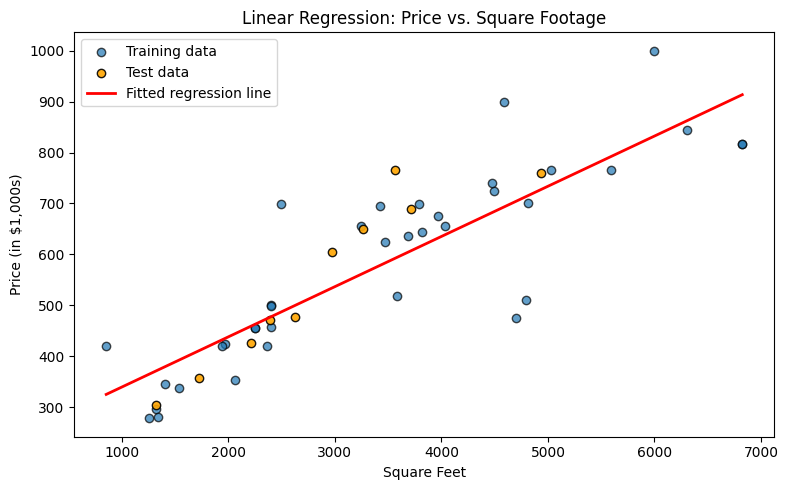

In [ ]:
# Build a smooth range of square footage values spanning the observed data.
# Wrapped in a DataFrame with the original column name so StandardScaler
# (fit on a DataFrame) doesn't warn about missing feature names.
sqft_range = np.linspace(df["Square Feet"].min(), df["Square Feet"].max(), 200)
sqft_range_df = pd.DataFrame({"Square Feet": sqft_range})
sqft_range_scaled = scaler.transform(sqft_range_df)  # must scale with the SAME scaler used for training
price_line = model.predict(sqft_range_scaled)

plt.scatter(X_train["Square Feet"], y_train, alpha=0.7, edgecolor="k", label="Training data")
plt.scatter(X_test["Square Feet"], y_test, alpha=0.9, edgecolor="k", color="orange", label="Test data")
plt.plot(sqft_range, price_line, color="red", linewidth=2, label="Fitted regression line")

plt.xlabel("Square Feet")
plt.ylabel("Price (in $1,000s)")
plt.title("Linear Regression: Price vs. Square Footage")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Other visualizations worth showing students

A single fitted line hides a lot. These additional plots are standard practice
for actually diagnosing a regression model, and are good material to walk
through with students.

### 13a. Predicted vs. actual price
If the model were perfect, every point would sit exactly on the diagonal
line. Deviation from the diagonal shows over- and under-prediction directly.


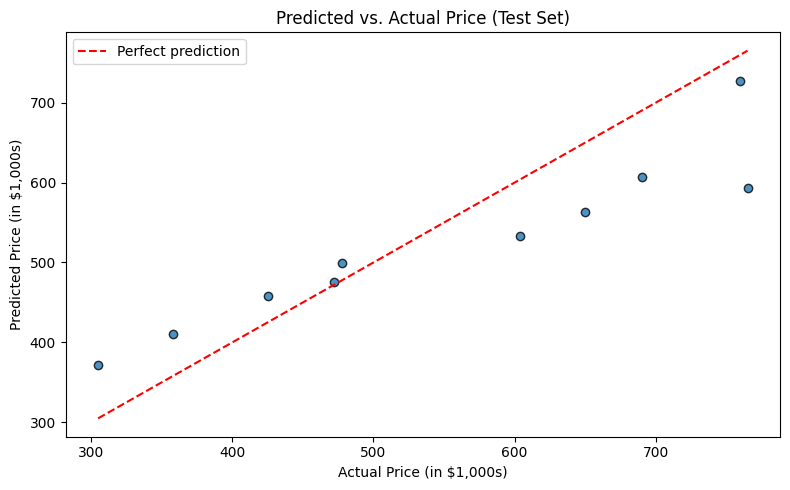

In [ ]:
plt.scatter(y_test, y_pred, edgecolor="k", alpha=0.8)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (in $1,000s)")
plt.ylabel("Predicted Price (in $1,000s)")
plt.title("Predicted vs. Actual Price (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


### 13b. Residual plot
Residuals = actual − predicted. Plotting residuals against the predictor
checks a core linear regression assumption: residuals should be scattered
randomly around zero with no obvious pattern. A visible curve or funnel shape
would suggest the linear model is missing something (e.g., a non-linear
relationship, or that price variance grows with home size).


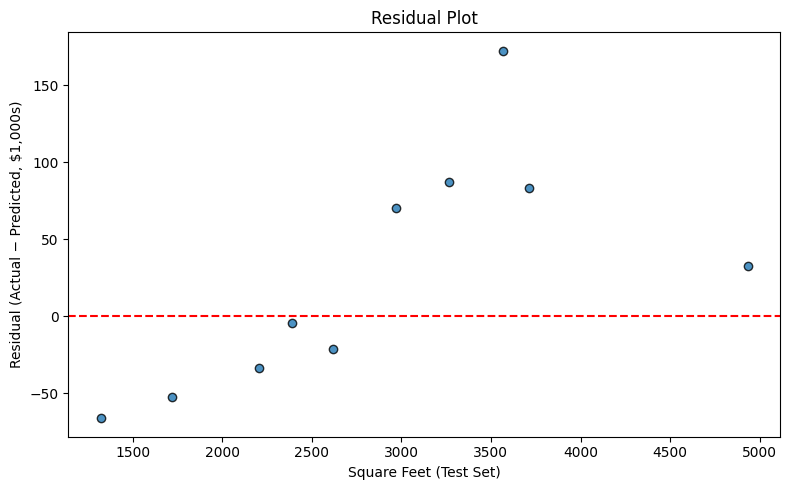

In [ ]:
residuals = y_test - y_pred

plt.scatter(X_test["Square Feet"], residuals, edgecolor="k", alpha=0.8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Square Feet (Test Set)")
plt.ylabel("Residual (Actual − Predicted, $1,000s)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


### 13c. Distribution of home prices
A histogram of the target variable itself is worth showing early in any
regression unit — it tells students what "average" and "spread" look like for
the thing they're trying to predict, before any model is involved.


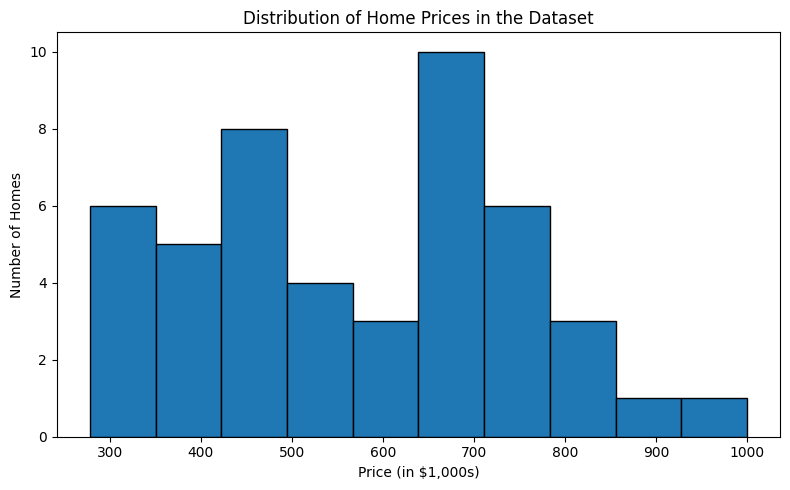

In [ ]:
plt.hist(df["Price_thousands"], bins=10, edgecolor="k")
plt.xlabel("Price (in $1,000s)")
plt.ylabel("Number of Homes")
plt.title("Distribution of Home Prices in the Dataset")
plt.tight_layout()
plt.show()


## 14. Discussion prompts for a PD session

- Why might scaling a single feature have no effect on R² here, but matter a
  great deal in the multi-feature notebook?
- What would happen to the test-set R² if `random_state` were changed?
  Try it, and discuss what that instability implies about small datasets.
- The residual plot: is there a pattern, or does it look like random scatter?
  What would a pattern imply about the model's assumptions?
- What other variables (not in this dataset) do you think would improve the
  prediction, and why?
- Continue to `LR_Multiple_Features.ipynb` to see how adding bedrooms,
  bathrooms, and house type changes the fitted weights and the model's
  accuracy.
